## Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms, models
import pandas as pd
import os
from PIL import Image
import copy
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

## Setup Paths

**Note:** Please modify the paths below to the your own paths, and change the CSV file to the lastest testing path.

In [ ]:
#TRAINING DATA PATH
# This should be the CSV that has the Gold + Pseudo-labels
TRAIN_CSV_PATH = '/content/drive/MyDrive/Wound_Assessment/Training_Master_Sheets/Training_Master_Round4_0.90.csv'

# Processed wound images
PROCESSED_SSL_DIR = '/content/drive/MyDrive/Wound_Assessment/data/segmented_images/SSL_Processed_Final/'

## Hyperparameters

In [ ]:
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
NUM_EPOCHS = 40

In [ ]:
#Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data Transformations

In [ ]:
data_transforms = {
    'train': transforms.Compose([
        # Data Augmentation
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),   # Added: Wounds can be captured from any angle
        transforms.RandomRotation(degrees=15),  # Keep your baseline rotation

        # Formatting
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),

    'val': transforms.Compose([
        # Standardize without changing the actual data
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

print("Data Augmentation is ready.")

Data Augmentation is ready.


## Multi-Task Dataset Class

In [ ]:
class WoundSSLDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load image from the specific directory stored in the CSV
        img_path = os.path.join(row['image_dir'], row['filename'])
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # Labels for the 3 tasks (Infection, Moisture, Edge)
        labels = {
            'inf': torch.tensor(int(row['Final_Inf']), dtype=torch.long),
            'moist': torch.tensor(int(row['Final_Moist']), dtype=torch.long),
            'edge': torch.tensor(int(row['Final_Edge']), dtype=torch.long)
        }

        return image, labels

## Define Model Architecture

In [ ]:
class ProposedMultiTaskModel(nn.Module):
    def __init__(self):
        super(ProposedMultiTaskModel, self).__init__()

        # Load EfficientNet-B0 with Pre-trained Weights
        self.backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

        # Extract the number of input features going into the classifier
        num_ftrs = self.backbone.classifier[1].in_features

        # Remove the original single-task classifier
        self.backbone.classifier = nn.Identity()

        # Define 3 separate 'Heads' for I.M.E. tasks

        # Infection Head
        self.head_inf = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 2)   # Infection (0=No, 1=Yes)
        )

        # Moisture Head
        self.head_moist = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 3)   # Moisture (0=Dry, 1=Moist, 2=Wet)
        )

        # Edge Head
        self.head_edge = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 2)   # Edge (0=No, 1=Yes)
        )

    def forward(self, x):
        # Feature extraction
        features = self.backbone(x)

        # Multi-task outputs
        out_inf = self.head_inf(features)
        out_moist = self.head_moist(features)
        out_edge = self.head_edge(features)

        return out_inf, out_moist, out_edge

# Move model to DEVICE (GPU/CPU)
model = ProposedMultiTaskModel().to(DEVICE)
print(" Multi-Task EfficientNet-B0 Model initialized.")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 150MB/s]


 Multi-Task EfficientNet-B0 Model initialized.


## Calculate Class Weights

In [ ]:
def calculate_task_weights(df, column_name):
    # Only look at valid labels (exclude -1)
    valid_data = df[df[column_name] != -1][column_name]

    # Count occurrences of each class
    class_counts = valid_data.value_counts().sort_index().values
    num_samples = len(valid_data)
    num_classes = len(class_counts)

    # Compute Inverse Frequency: Total_Samples / (Num_Classes * Class_Samples)
    weights = num_samples / (num_classes * class_counts)

    return torch.tensor(weights, dtype=torch.float).to(DEVICE)

## Training Function

In [ ]:
def train_one_epoch(model, loader, optimizer, device, criterion_inf, criterion_moist, criterion_edge):
    model.train()
    total_loss = 0

    # Unpack 'labels' as a dictionary from loader
    for images, labels in loader:
        images = images.to(device)

        # Extract specific task labels from the dictionary
        inf_labels = labels['inf'].to(device)
        moist_labels = labels['moist'].to(device)
        edge_labels = labels['edge'].to(device)

        optimizer.zero_grad()

        # Forward pass
        out_inf, out_moist, out_edge = model(images)

        # Calculate individual losses
        loss_inf = criterion_inf(out_inf, inf_labels)
        loss_moist = criterion_moist(out_moist, moist_labels)
        loss_edge = criterion_edge(out_edge, edge_labels)

        # Combined Multi-Task Loss
        # Formula: $$L_{total} = L_{inf} + L_{moist} + L_{edge}$$
        batch_loss = loss_inf + loss_moist + loss_edge

        # Backward pass and Optimization
        batch_loss.backward()
        optimizer.step()

        total_loss += batch_loss.item()

    return total_loss / len(loader)

## Validation Function

In [ ]:
from sklearn.metrics import recall_score, f1_score

def validate_one_epoch(model, loader, device, criterion_inf, criterion_moist, criterion_edge):
    model.eval()
    results = {
        'inf': {'preds': [], 'labels': []},
        'moist': {'preds': [], 'labels': []},
        'edge': {'preds': [], 'labels': []}
    }

    val_loss = 0

    with torch.no_grad():

        for images, labels in loader:
            images = images.to(device)

            # Extract labels
            inf_l = labels['inf'].to(device)
            moist_l = labels['moist'].to(device)
            edge_l = labels['edge'].to(device)

            # Forward pass
            out_inf, out_moist, out_edge = model(images)

            # Calculate validation loss
            loss_inf = criterion_inf(out_inf, inf_l)
            loss_moist = criterion_moist(out_moist, moist_l)
            loss_edge = criterion_edge(out_edge, edge_l)
            val_loss += (loss_inf + loss_moist + loss_edge).item()

            # Extract outputs
            tasks = ['inf', 'moist', 'edge']
            outputs = [out_inf, out_moist, out_edge]
            labels_list = [inf_l, moist_l, edge_l]

            for task, output, labels_val in zip(tasks, outputs, labels_list):
                preds = torch.argmax(output, dim=1).cpu().numpy()
                lbls = labels_val.cpu().numpy()

                # Filter out -1
                mask = lbls != -1
                results[task]['preds'].extend(preds[mask])
                results[task]['labels'].extend(lbls[mask])

    # Calculate Macro metrics
    metrics = {'loss': val_loss / len(loader)}
    for task in ['inf', 'moist', 'edge']:

        if len(results[task]['labels']) > 0:
            metrics[f'f1_{task}'] = f1_score(results[task]['labels'], results[task]['preds'], average='macro', zero_division=0)
            metrics[f'recall_{task}'] = recall_score(results[task]['labels'], results[task]['preds'], average='macro', zero_division=0)
        else:
            metrics[f'f1_{task}'] = 0.0
            metrics[f'recall_{task}'] = 0.0

    return metrics

## Model Training

In [ ]:
# Load the data
master_df = pd.read_csv(TRAIN_CSV_PATH)

# Split and CLEAN the index
df_original = master_df[master_df['source'] == 'expert'].reset_index(drop=True)
df_ssl = master_df[master_df['source'] == 'pseudo'].reset_index(drop=True)

print(f"Expert rows ready: {len(df_original)}")
print(f"Pseudo rows ready: {len(df_ssl)}")

Expert rows ready: 107
Pseudo rows ready: 2572


In [ ]:
fold_metrics_loss = [] # Summary for loss-based models
fold_metrics_f1 = []   # Summary for F1-based models

for fold in range(5):
    print(f"\n{'='*20} STARTING STUDENT FOLD {fold+1}/5 {'='*20}")

    # SSL DATA SPLIT
    val_df = df_original[df_original['fold'] == fold].reset_index(drop=True)

    # Training is (Remaining Expert images) + (ALL Pseudo-labels)
    expert_train_part = df_original[df_original['fold'] != fold]

    # Assign sample weights before concatenation
    expert_train_part = expert_train_part.copy()
    expert_train_part['sample_weight'] = 10  # Higher weight for expert data

    df_ssl_copy = df_ssl.copy()
    df_ssl_copy['sample_weight'] = 1         # Lower weight for pseudo-labels

    train_df = pd.concat([expert_train_part, df_ssl_copy], ignore_index=True).reset_index(drop=True)

    # DYNAMIC TASK WEIGHTS
    # Recalculate weights for this specific fold
    w_inf = calculate_task_weights(train_df, 'Final_Inf')
    w_moist = calculate_task_weights(train_df, 'Final_Moist')
    w_edge = calculate_task_weights(train_df, 'Final_Edge')

    # Update criteria with these new weights
    criterion_inf = nn.CrossEntropyLoss(weight=w_inf, ignore_index=-1).to(DEVICE)
    criterion_moist = nn.CrossEntropyLoss(weight=w_moist, ignore_index=-1).to(DEVICE)
    criterion_edge = nn.CrossEntropyLoss(weight=w_edge, ignore_index=-1).to(DEVICE)

    # DATA LOADERS & BALANCED SAMPLING
    train_ds = WoundSSLDataset(train_df, transform=data_transforms['train'])
    val_ds = WoundSSLDataset(val_df, transform=data_transforms['val'])

    # Weighted Sampler
    weights = train_df['sample_weight'].values
    sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

    # Use sampler for training // standard shuffle=False for validation
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    # FRESH STUDENT MODEL
    model = ProposedMultiTaskModel().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    best_val_loss = float('inf')
    best_f1_moist = 0.0

    best_metrics_loss = {}
    best_metrics_f1 = {}

    for epoch in range(NUM_EPOCHS):
        # Training Phase
        train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE,
                                     criterion_inf, criterion_moist, criterion_edge)

        # Validation Phase
        val_metrics = validate_one_epoch(model, val_loader, DEVICE,
                                         criterion_inf, criterion_moist, criterion_edge)

        # Checkpoint based on Validation Loss
        # CHECKPOINT 1: Best Global Loss
        if val_metrics['loss'] < best_val_loss:
            best_val_loss = val_metrics['loss']
            best_metrics_loss = val_metrics
            torch.save(model.state_dict(), f"Best_SSL_Student_Fold{fold}_Loss.pth")

        # CHECKPOINT 2: Best Moisture F1
        if val_metrics['f1_moist'] > best_f1_moist + 1e-4:
            best_f1_moist = val_metrics['f1_moist']
            best_metrics_f1 = val_metrics
            torch.save(model.state_dict(), f"Best_SSL_Student_Fold{fold}_MoistF1.pth")

        # Independent Task Logging
        print(f"Ep {epoch+1:02d} | Loss: {val_metrics['loss']:.3f} | "
              f"INF (F1:{val_metrics['f1_inf']:.2f}, Rec:{val_metrics['recall_inf']:.2f}) | "
              f"MOIST (F1:{val_metrics['f1_moist']:.2f}, Rec:{val_metrics['recall_moist']:.2f}) | "
              f"EDGE (F1:{val_metrics['f1_edge']:.2f}, Rec:{val_metrics['recall_edge']:.2f})")


    fold_metrics_loss.append(best_metrics_loss)
    fold_metrics_f1.append(best_metrics_f1)

    print(f" Fold {fold+1} Finished. Best Val Loss: {best_val_loss:.4f}")
    print(f" Fold {fold+1} Finished. Best F1 Moist: {best_f1_moist:.4f}")


==================== STARTING STUDENT FOLD 1/5 ====================
Ep 01 | Loss: 3.960 | INF (F1:0.65, Rec:0.69) | MOIST (F1:0.39, Rec:0.54) | EDGE (F1:0.65, Rec:0.75)
Ep 02 | Loss: 3.354 | INF (F1:0.70, Rec:0.73) | MOIST (F1:0.50, Rec:0.53) | EDGE (F1:0.86, Rec:0.86)
Ep 03 | Loss: 2.592 | INF (F1:0.70, Rec:0.73) | MOIST (F1:0.35, Rec:0.40) | EDGE (F1:0.74, Rec:0.78)
Ep 04 | Loss: 4.419 | INF (F1:0.76, Rec:0.78) | MOIST (F1:0.43, Rec:0.56) | EDGE (F1:0.80, Rec:0.82)
Ep 05 | Loss: 6.890 | INF (F1:0.81, Rec:0.83) | MOIST (F1:0.43, Rec:0.56) | EDGE (F1:0.77, Rec:0.76)
Ep 06 | Loss: 5.216 | INF (F1:0.76, Rec:0.78) | MOIST (F1:0.47, Rec:0.59) | EDGE (F1:0.92, Rec:0.90)
Ep 07 | Loss: 4.215 | INF (F1:0.76, Rec:0.78) | MOIST (F1:0.47, Rec:0.59) | EDGE (F1:0.72, Rec:0.72)
Ep 08 | Loss: 3.836 | INF (F1:0.70, Rec:0.73) | MOIST (F1:0.52, Rec:0.62) | EDGE (F1:0.61, Rec:0.63)
Ep 09 | Loss: 3.981 | INF (F1:0.69, Rec:0.70) | MOIST (F1:0.47, Rec:0.59) | EDGE (F1:0.77, Rec:0.76)
Ep 10 | Loss: 4.156 | 

## Results

In [ ]:
def print_summary(summary_list, title):
    print(f"\n{'='*40}\n {title} \n{'='*40}")
    for task in ['inf', 'moist', 'edge']:
        avg_f1 = np.mean([m[f'f1_{task}'] for m in summary_list])
        std_f1 = np.std([m[f'f1_{task}'] for m in summary_list])
        avg_rec = np.mean([m[f'recall_{task}'] for m in summary_list])
        print(f"Task: {task.upper():<6} | Macro-F1: {avg_f1:.4f} ± {std_f1:.3f} | Macro-Recall: {avg_rec:.4f}")

print_summary(fold_metrics_loss, "SAVED BY TOTAL LOSS")
print_summary(fold_metrics_f1, "SAVED BY MOISTURE F1")


 SAVED BY TOTAL LOSS 
Task: INF    | Macro-F1: 0.7379 ± 0.082 | Macro-Recall: 0.7558
Task: MOIST  | Macro-F1: 0.5231 ± 0.169 | Macro-Recall: 0.5924
Task: EDGE   | Macro-F1: 0.7841 ± 0.092 | Macro-Recall: 0.7999

 SAVED BY MOISTURE F1 
Task: INF    | Macro-F1: 0.7408 ± 0.098 | Macro-Recall: 0.7522
Task: MOIST  | Macro-F1: 0.5980 ± 0.155 | Macro-Recall: 0.6921
Task: EDGE   | Macro-F1: 0.8107 ± 0.153 | Macro-Recall: 0.8096


## Model Evaluation and Confusion Matrix

 EVALUATING STRATEGY: Loss
--- Evaluating SSL Fold 1/5 ---
--- Evaluating SSL Fold 2/5 ---
--- Evaluating SSL Fold 3/5 ---
--- Evaluating SSL Fold 4/5 ---
--- Evaluating SSL Fold 5/5 ---

====================  FINAL REPORT FOR Loss STRATEGY ====================

 INFECTION PERFORMANCE:
              precision    recall  f1-score   support

Non-Infected       0.86      0.80      0.83        71
    Infected       0.65      0.74      0.69        35

    accuracy                           0.78       106
   macro avg       0.76      0.77      0.76       106
weighted avg       0.79      0.78      0.79       106


 MOISTURE PERFORMANCE:
              precision    recall  f1-score   support

         Dry       0.50      0.54      0.52        13
       Moist       0.88      0.74      0.81        78
         Wet       0.37      0.62      0.47        16

    accuracy                           0.70       107
   macro avg       0.58      0.64      0.60       107
weighted avg       0.76      0.70   

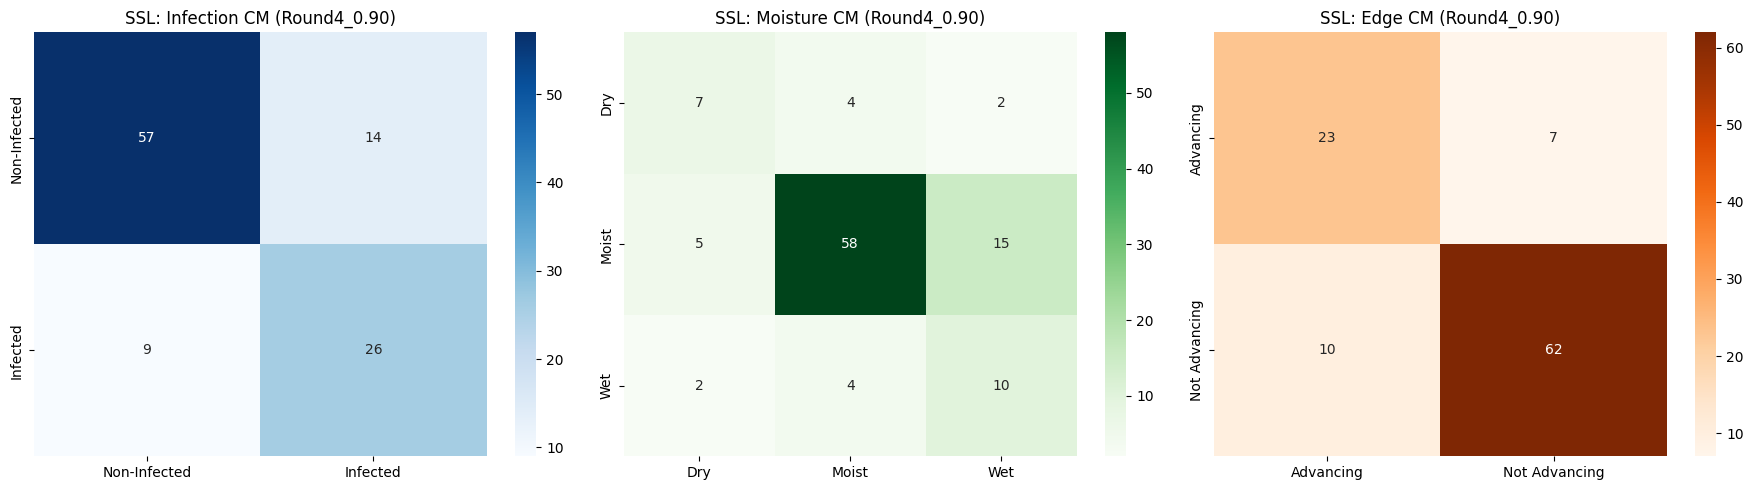

 EVALUATING STRATEGY: F1
--- Evaluating SSL Fold 1/5 ---
--- Evaluating SSL Fold 2/5 ---
--- Evaluating SSL Fold 3/5 ---
--- Evaluating SSL Fold 4/5 ---
--- Evaluating SSL Fold 5/5 ---

====================  FINAL REPORT FOR F1 STRATEGY ====================

 INFECTION PERFORMANCE:
              precision    recall  f1-score   support

Non-Infected       0.85      0.86      0.85        71
    Infected       0.71      0.69      0.70        35

    accuracy                           0.80       106
   macro avg       0.78      0.77      0.77       106
weighted avg       0.80      0.80      0.80       106


 MOISTURE PERFORMANCE:
              precision    recall  f1-score   support

         Dry       0.50      0.62      0.55        13
       Moist       0.90      0.81      0.85        78
         Wet       0.48      0.62      0.54        16

    accuracy                           0.76       107
   macro avg       0.63      0.68      0.65       107
weighted avg       0.79      0.76      0

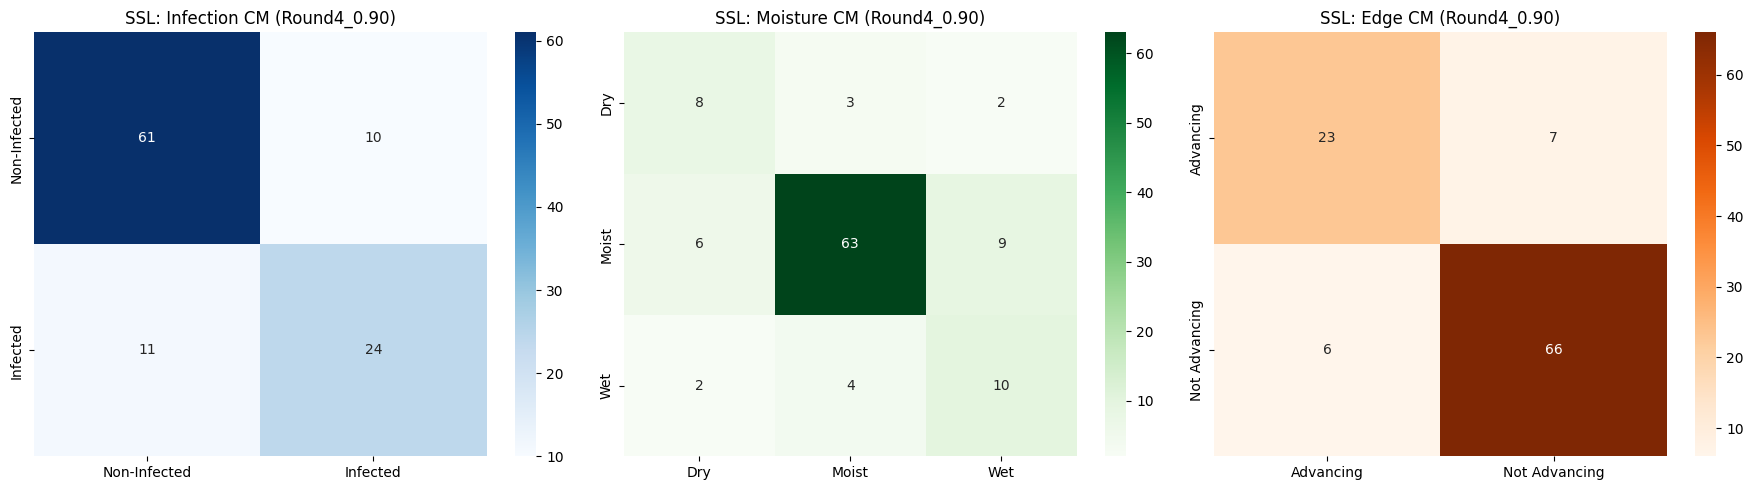

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Standardize Target Names
target_names_inf = ["Non-Infected", "Infected"]
target_names_moist = ["Dry", "Moist", "Wet"]
target_names_edge = ["Advancing", "Not Advancing"]

evaluation_results_storage = {}

for model_strategy in ["Loss", "F1"]:

    # Storage for Global Metrics
    all_true_inf, all_preds_inf = [], []
    all_true_moist, all_preds_moist = [], []
    all_true_edge, all_preds_edge = [], []

    print(f" EVALUATING STRATEGY: {model_strategy}")

    for fold in range(5):
        print(f"--- Evaluating SSL Fold {fold+1}/5 ---")

        # Load Expert Validation Data
        val_df = df_original[df_original['fold'] == fold].reset_index(drop=True)
        val_ds = WoundSSLDataset(val_df, transform=data_transforms['val'])
        val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

        # Load the Student Model
        model = ProposedMultiTaskModel().to(DEVICE)

        if model_strategy == "Loss":
            model_path_suffix = "Loss"
        elif model_strategy == "F1":
            model_path_suffix = "MoistF1" # Training saves as MoistF1, not just F1
        model_path = f"Best_SSL_Student_Fold{fold}_{model_path_suffix}.pth"

        try:
            model.load_state_dict(torch.load(model_path, map_location=DEVICE))
            model.eval()
        except FileNotFoundError:
            print(f" Warning: {model_path} not found. Skipping.")
            continue

        # Generate Predictions
        with torch.no_grad():
            for images, labels_dict in val_loader:
                images = images.to(DEVICE)

                # Unpack labels from the dictionary
                l_inf = labels_dict['inf']
                l_moist = labels_dict['moist']
                l_edge = labels_dict['edge']

                # Forward pass
                out_inf, out_moist, out_edge = model(images)

                # Convert to class indices
                preds_inf = torch.argmax(out_inf, dim=1).cpu().numpy()
                preds_moist = torch.argmax(out_moist, dim=1).cpu().numpy()
                preds_edge = torch.argmax(out_edge, dim=1).cpu().numpy()

                # Store
                all_true_inf.extend(l_inf.numpy())
                all_preds_inf.extend(preds_inf)

                all_true_moist.extend(l_moist.numpy())
                all_preds_moist.extend(preds_moist)

                all_true_edge.extend(l_edge.numpy())
                all_preds_edge.extend(preds_edge)

    def filter_missing(y_true, y_pred):
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        mask = y_true != -1
        return y_true[mask], y_pred[mask]

    # FINAL SSL PERFORMANCE REPORTS
    print(f"\n{'='*20}  FINAL REPORT FOR {model_strategy} STRATEGY {'='*20}")

    # 1. Infection Report
    clean_true_i, clean_pred_i = filter_missing(all_true_inf, all_preds_inf)

    if len(clean_true_i) > 0:
        print("\n INFECTION PERFORMANCE:")
        print(classification_report(clean_true_i, clean_pred_i, target_names=target_names_inf))
    else:
        print("\n INFECTION PERFORMANCE: No data available for report.")


    # 2. Moisture Report
    clean_true_m, clean_pred_m = filter_missing(all_true_moist, all_preds_moist)
    if len(clean_true_m) > 0:
        print("\n MOISTURE PERFORMANCE:")
        print(classification_report(clean_true_m, clean_pred_m, target_names=target_names_moist))
    else:
        print("\n MOISTURE PERFORMANCE: No data available for report.")


    # 3. Edge Report
    clean_true_e, clean_pred_e = filter_missing(all_true_edge, all_preds_edge)
    if len(clean_true_e) > 0:
        print("\n EDGE PERFORMANCE:")
        print(classification_report(clean_true_e, clean_pred_e, target_names=target_names_edge))
    else:
        print("\n EDGE PERFORMANCE: No data available for report.")


    # PLOT CONFUSION MATRICES
    if len(clean_true_i) > 0 or len(clean_true_m) > 0 or len(clean_true_e) > 0:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # Infection Matrix
        if len(clean_true_i) > 0:
            sns.heatmap(confusion_matrix(clean_true_i, clean_pred_i), annot=True, fmt='d', cmap='Blues',
                        xticklabels=target_names_inf, yticklabels=target_names_inf, ax=axes[0])
            axes[0].set_title('SSL: Infection CM (Round4_0.90)')
        else:
            axes[0].set_title('SSL: Infection CM (No Data)')
            axes[0].axis('off')

        # Moisture Matrix
        if len(clean_true_m) > 0:
            sns.heatmap(confusion_matrix(clean_true_m, clean_pred_m), annot=True, fmt='d', cmap='Greens',
                        xticklabels=target_names_moist, yticklabels=target_names_moist, ax=axes[1])
            axes[1].set_title('SSL: Moisture CM (Round4_0.90)')
        else:
            axes[1].set_title('SSL: Moisture CM (No Data)')
            axes[1].axis('off')

        # Edge Matrix
        if len(clean_true_e) > 0:
            sns.heatmap(confusion_matrix(clean_true_e, clean_pred_e), annot=True, fmt='d', cmap='Oranges',
                        xticklabels=target_names_edge, yticklabels=target_names_edge, ax=axes[2])
            axes[2].set_title('SSL: Edge CM (Round4_0.90)')
        else:
            axes[2].set_title('SSL: Edge CM (No Data)')
            axes[2].axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print("\n No data available for plotting confusion matrices.")

    evaluation_results_storage[model_strategy] = {
        'i': (clean_true_i, clean_pred_i),
        'm': (clean_true_m, clean_pred_m),
        'e': (clean_true_e, clean_pred_e)
    }

## Calculate Medical Metrics (Sensitivity/ Specificity) & Save

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
import os

def get_medical_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    # Binary Case (Infection & Edge)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        accuracy = (tp + tn) / (tp + tn + fp + fn)
        return sensitivity, specificity, accuracy
    # Multi-class Case (Moisture)
    else:
        acc = accuracy_score(y_true, y_pred)
        return None, None, acc

for strategy_name, data in evaluation_results_storage.items():

    # Update the tag for each strategy
    experiment_tag = f"SSL_Round4_0.90_{strategy_name}_Strategy"
    print(f"\n{'='*40}")
    print(f" Generating Thesis-Grade Report for: {experiment_tag}...")

    # Extract the stored "clean" variables for this specific strategy
    c_true_i, c_pred_i = data['i']
    c_true_m, c_pred_m = data['m']
    c_true_e, c_pred_e = data['e']

    # Calculate Metrics using Student Evaluation variables
    sens_inf, spec_inf, acc_inf = get_medical_metrics(c_true_i, c_pred_i)
    f1_inf = f1_score(c_true_i, c_pred_i, average='macro')

    _, _, acc_moist = get_medical_metrics(c_true_m, c_pred_m)
    f1_moist = f1_score(c_true_m, c_pred_m, average='macro')

    sens_edge, spec_edge, acc_edge = get_medical_metrics(c_true_e, c_pred_e)
    f1_edge = f1_score(c_true_e, c_pred_e, average='macro')

    # Create the Dataframe
    results_data = {
        "Metric": ["Accuracy", "Sensitivity (Recall)", "Specificity", "Macro F1-Score"],
        "Infection": [acc_inf, sens_inf, spec_inf, f1_inf],
        "Moisture":  [acc_moist, "N/A (Multi-class)", "N/A (Multi-class)", f1_moist],
        "Edge":      [acc_edge, sens_edge, spec_edge, f1_edge]
    }

    results_df = pd.DataFrame(results_data)

    for col in ["Infection", "Moisture", "Edge"]:
        results_df[col] = results_df[col].apply(lambda x: round(x, 4) if isinstance(x, (float, int)) else x)

    # Save to Drive
    # Change filename to ensure not overwriting baseline
    save_filename = f'{experiment_tag}_Final_Metrics.csv'
    save_path = os.path.join('/content/drive/MyDrive/Wound_Assessment/Result_Summary', save_filename)
    results_df.to_csv(save_path, index=False)

    print(f"\n Results saved to: {save_path}")
    print(f"\n{experiment_tag} Final Summary")
    print(results_df.to_string(index=False))


 Generating Thesis-Grade Report for: SSL_Round4_0.90_Loss_Strategy...

 Results saved to: /content/drive/MyDrive/Wound_Assessment/SSL_Round4_0.90_Loss_Strategy_Final_Metrics.csv

--- SSL_Round4_0.90_Loss_Strategy Final Summary ---
              Metric  Infection          Moisture   Edge
            Accuracy     0.7830            0.7009 0.8333
Sensitivity (Recall)     0.7429 N/A (Multi-class) 0.8611
         Specificity     0.8028 N/A (Multi-class) 0.7667
      Macro F1-Score     0.7627            0.5964 0.8048

 Generating Thesis-Grade Report for: SSL_Round4_0.90_F1_Strategy...

 Results saved to: /content/drive/MyDrive/Wound_Assessment/SSL_Round4_0.90_F1_Strategy_Final_Metrics.csv

--- SSL_Round4_0.90_F1_Strategy Final Summary ---
              Metric  Infection          Moisture   Edge
            Accuracy     0.8019             0.757 0.8725
Sensitivity (Recall)     0.6857 N/A (Multi-class) 0.9167
         Specificity     0.8592 N/A (Multi-class) 0.7667
      Macro F1-Score     0.77

## Save Model

In [ ]:
save_path = '/content/drive/MyDrive/Wound_Assessment/models'

os.makedirs(save_path, exist_ok=True)

In [ ]:
import shutil

# Identify the best model for each category
best_loss_idx = np.argmin([m['loss'] for m in fold_metrics_loss])
best_f1_idx = np.argmax([m['f1_moist'] for m in fold_metrics_f1])

# Archive the Best Model for Loss
loss_src = f"Best_SSL_Student_Fold{best_loss_idx}_Loss.pth"
loss_dest = os.path.join(save_path, 'SSL_IME_Round4_0.90_Loss.pth')
if os.path.exists(loss_src):
    shutil.copy(loss_src, loss_dest)
    print(f"Best Model for Total Loss (Fold {best_loss_idx+1}) saved to: {loss_dest}")

# Archive the Best Model for Moisture F1
f1_src = f"Best_SSL_Student_Fold{best_f1_idx}_MoistF1.pth"
f1_dest = os.path.join(save_path, 'SSL_IME_Round4_0.90_F1Moist.pth')
if os.path.exists(f1_src):
    shutil.copy(f1_src, f1_dest)
    print(f"Best Model for Moisture F1 (Fold {best_f1_idx+1}) saved to: {f1_dest}")

print("\nBest Model archiving complete.")

Best Model for Total Loss (Fold 4) saved to: /content/drive/MyDrive/Wound_Assessment/models/SSL_IME_Round4_0.90_Loss.pth
Best Model for Moisture F1 (Fold 4) saved to: /content/drive/MyDrive/Wound_Assessment/models/SSL_IME_Round4_0.90_F1Moist.pth

Best Model archiving complete.
